# Public Opinion Research Project

## Academic Companion Notebook

This notebook is the academic-facing companion to the capstone blueprint. Unlike the archived original delivery notebook, this one is intentionally honest about the current stage of the project: it is a research design notebook rather than a finished empirical analysis.

### Abstract

The capstone is designed to study how economic expectations, institutional trust, issue salience, media environments, and sociodemographic differences shape political attitudes and behavior. The repository now formalizes that intention through a theoretical framework, a measurement blueprint, a methodological test plan, a validity matrix, and a delivery roadmap.

### Core claim

A serious public-opinion project should make its theory, constructs, and inferential limits explicit before any final results are reported. This notebook shows that architecture.


In [1]:
from pathlib import Path
from IPython.display import Image, Markdown, display
import pandas as pd

BASE_DIR = Path.cwd()
required_paths = [
    BASE_DIR / 'outputs/tables/hypothesis_matrix.csv',
    BASE_DIR / 'outputs/tables/theoretical_framework.csv',
    BASE_DIR / 'outputs/tables/measurement_blueprint.csv',
    BASE_DIR / 'outputs/tables/methodological_test_plan.csv',
    BASE_DIR / 'outputs/tables/validity_matrix.csv',
    BASE_DIR / 'outputs/tables/deliverable_roadmap.csv',
]
missing = [str(path.relative_to(BASE_DIR)) for path in required_paths if not path.exists()]
if missing:
    raise FileNotFoundError(f'Missing expected outputs: {missing}')
print('All required blueprint outputs are available.')


All required blueprint outputs are available.


In [2]:
hypotheses = pd.read_csv(BASE_DIR / 'outputs/tables/hypothesis_matrix.csv')
theory = pd.read_csv(BASE_DIR / 'outputs/tables/theoretical_framework.csv')
measurement = pd.read_csv(BASE_DIR / 'outputs/tables/measurement_blueprint.csv')
test_plan = pd.read_csv(BASE_DIR / 'outputs/tables/methodological_test_plan.csv')
validity = pd.read_csv(BASE_DIR / 'outputs/tables/validity_matrix.csv')
roadmap = pd.read_csv(BASE_DIR / 'outputs/tables/deliverable_roadmap.csv')

summary = pd.DataFrame([
    {'metric': 'Core hypotheses', 'value': str(len(hypotheses))},
    {'metric': 'Theoretical constructs', 'value': str(len(theory))},
    {'metric': 'Measurement domains', 'value': str(len(measurement))},
    {'metric': 'Methodological stages', 'value': str(len(test_plan))},
    {'metric': 'Validity risks tracked', 'value': str(len(validity))},
])
summary


,metric,value
0,Core hypotheses,6
1,Theoretical constructs,5
2,Measurement domains,5
3,Methodological stages,6
4,Validity risks tracked,5


## 1. Theoretical purpose

The capstone is designed around a connected explanation of political behavior rather than a loose collection of survey variables. The central idea is that citizens form political evaluations through interacting mechanisms:

- retrospective economic judgments,
- institutional trust,
- issue salience,
- media exposure,
- and sociodemographic position.

A good project should therefore begin by specifying constructs and mechanisms before deciding on model families.


In [3]:
display(Markdown('### Hypothesis matrix'))
display(hypotheses)
display(Markdown('### Theoretical framework'))
display(theory)


### Hypothesis matrix

,hypothesis_id,hypothesis,mechanism,core_variables,test_family,deliverable
0,H1,Economic expectations are associated with gove...,Pocketbook assessments and sociotropic expecta...,"Economic outlook, government approval, vote in...","Cross-tabulation, ordered logit, marginal effects",Probability profiles by economic sentiment seg...
1,H2,Institutional trust predicts turnout intention...,Trust reduces political alienation and raises ...,"Trust in institutions, turnout intention, refo...","Index construction, logistic regression, calib...",Trust index and turnout-probability table
2,H3,Issue salience segments the electorate into di...,Priority issues structure how voters map ident...,"Issue salience, ideology, candidate preference","MCA/PCA, clustering, silhouette diagnostics",Segment profiles and narrative personas
3,H4,Sociodemographic differences moderate the rela...,"Age, education, and class position shape how i...","Age, education, region, class proxies, politic...","Interaction models, subgroup contrasts, partia...",Heterogeneity matrix by subgroup
4,H5,Candidate evaluation is driven by both valence...,Voters reward competence cues but also anchor ...,"Candidate ratings, ideology, leadership traits","Factor analysis, multinomial logit, dominance ...",Relative importance of valence and ideology
5,H6,Media consumption patterns amplify differences...,Information environments mediate beliefs about...,"Media source, economic outlook, institutional ...","Difference-in-means, propensity-score weightin...",Media ecosystem comparison table


### Theoretical framework

,construct,theoretical_anchor,observable_proxies,why_it_matters
0,Retrospective voting,Voters reward or punish incumbents based on pe...,"Government approval, vote intention, economic ...",Connects subjective evaluations with concrete ...
1,Institutional trust,"Trust sustains compliance, turnout, and accept...","Confidence in Congress, courts, presidency, el...",Separates dissatisfaction with outcomes from d...
2,Issue salience,The issues voters prioritize structure what co...,"Top national problem, policy priorities, refor...",Supports segmentation and message design rathe...
3,Political behavior,Attitudes matter when they translate into part...,"Turnout intention, candidate preference, polic...",Keeps the capstone tied to behavioral outcomes...
4,Information environment,"Media exposure shapes priors, trust, and perce...","Primary media source, frequency of news consum...",Introduces a mechanism for heterogeneity and p...


## 2. Measurement strategy

The measurement layer is one of the biggest improvements in the repository. Instead of saying only that trust or ideology are important, the blueprint now specifies which observable proxies should be used and what analytical role each domain would play.

This matters because public-opinion projects often fail not at the modeling stage, but at the measurement stage.


In [4]:
measurement


,domain,example_items,preferred_scale,analytic_use
0,Economic outlook,"Personal finances, country trajectory, inflati...",Ordered categorical,Approval and vote models
1,Institutional trust,"Confidence in courts, congress, presidency, el...",Likert or ordinal composite,Turnout and legitimacy models
2,Issue salience,"Main national problem, most urgent reform, pol...",Top choice plus ranked preferences,Segmentation and heterogeneity analysis
3,Political behavior,"Turnout intention, vote intention, government ...","Binary, ordered, or multinomial",Outcome layer
4,Exposure and context,"Media source, education, age, class proxy, geo...",Categorical plus continuous controls,Moderation and robustness checks


## 3. Methodological test plan

The methodological design now moves through a clear sequence:

1. validate scales,
2. produce weighted descriptive baselines,
3. test headline contrasts,
4. estimate interpretable models,
5. segment the electorate,
6. stress-test the conclusions.

This sequence is strong because it prevents the capstone from becoming an unstructured notebook with disconnected charts and models.


In [5]:
test_plan


,stage,test,purpose,tools,output
0,Measurement,Reliability and dimensionality checks,"Validate scales for trust, ideology, and issue...","Cronbach alpha, polychoric PCA/factor analysis",Validated index specification
1,Description,Weighted descriptive tables and uncertainty bands,Summarize the electorate before moving to caus...,"Survey weights, confidence intervals, subgroup...",Clean descriptive baseline
2,Association,Difference-in-means and non-parametric distrib...,Check whether headline contrasts appear before...,"Mann-Whitney, Kruskal-Wallis, Spearman",First-pass evidence for each hypothesis
3,Modeling,"Logit, ordered logit, multinomial logit","Model turnout, approval, and vote intention us...","Marginal effects, calibration plots, ROC/AUC w...",Core inferential results
4,Segmentation,Latent or empirical clustering,Identify coherent voter blocs based on issue s...,"K-means, hierarchical clustering, silhouette a...",Electorate segments with narrative profiles
5,Robustness,"Alternative codings, reweighting, and sensitiv...",Test whether the conclusions depend on specifi...,"Bootstrap, propensity weights, alternative thr...",Credibility appendix


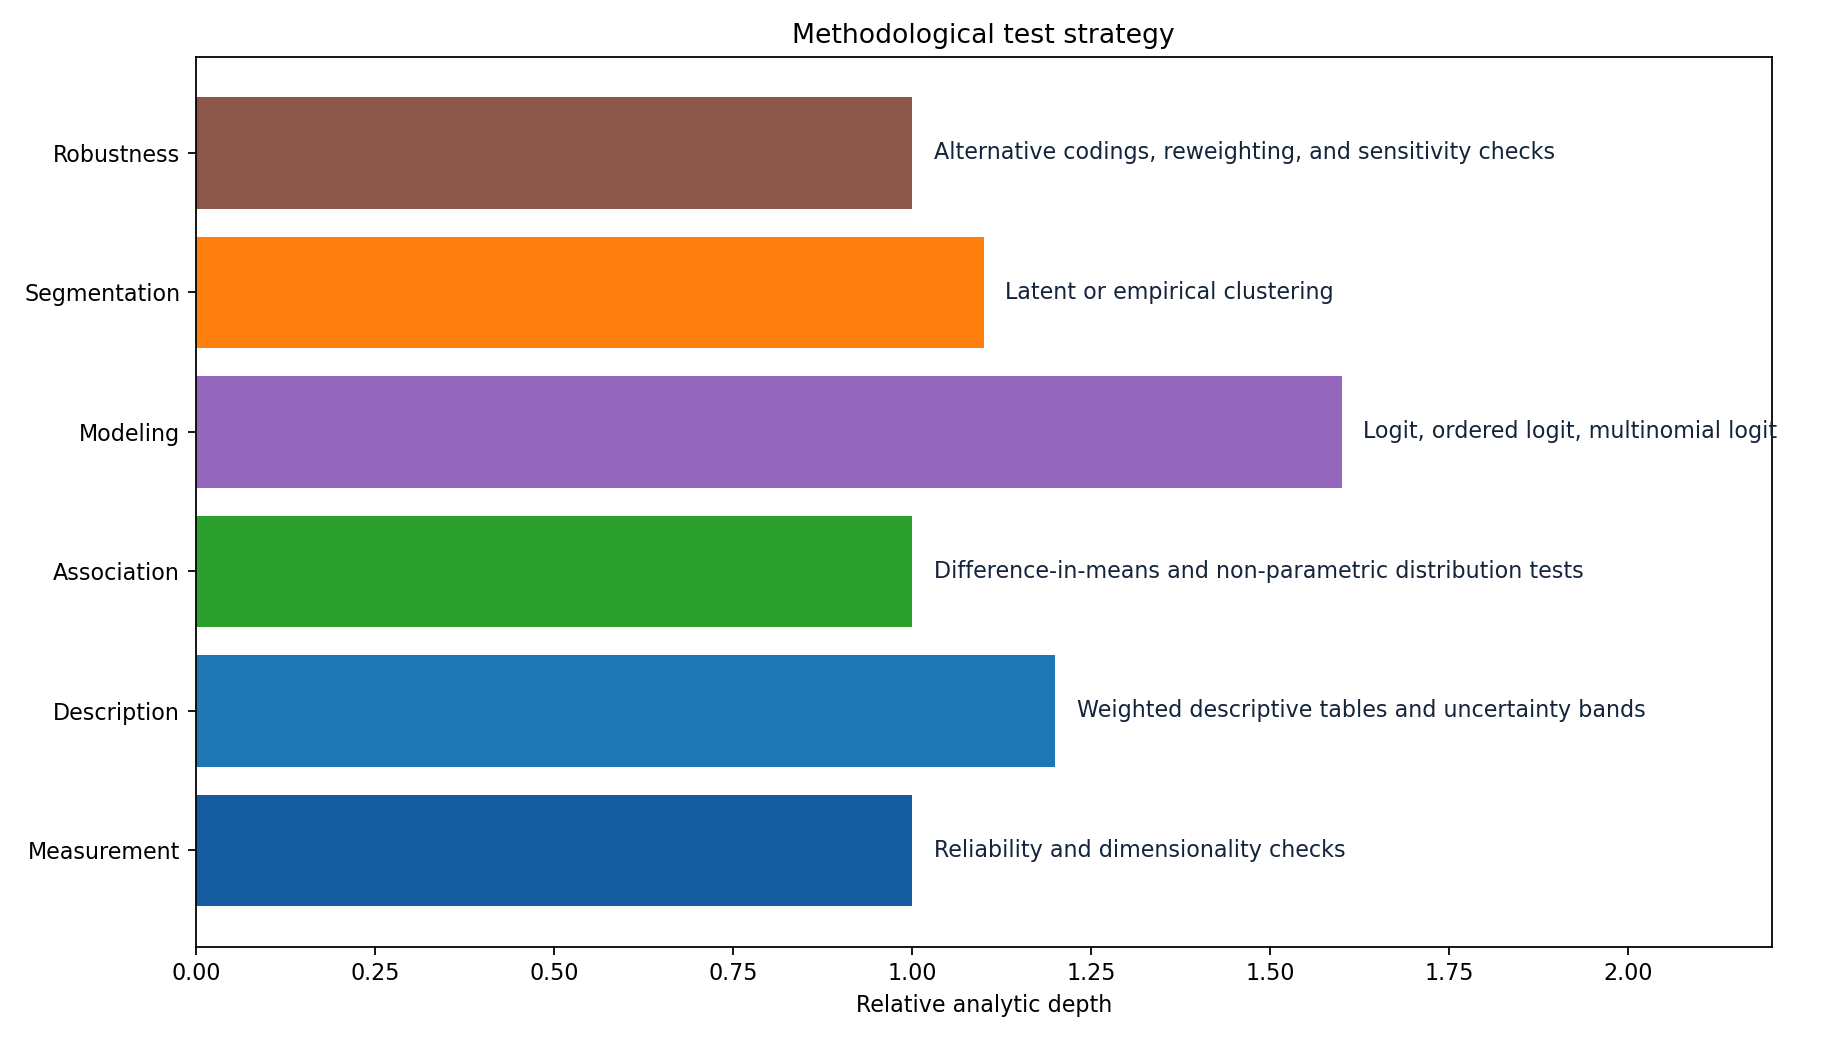

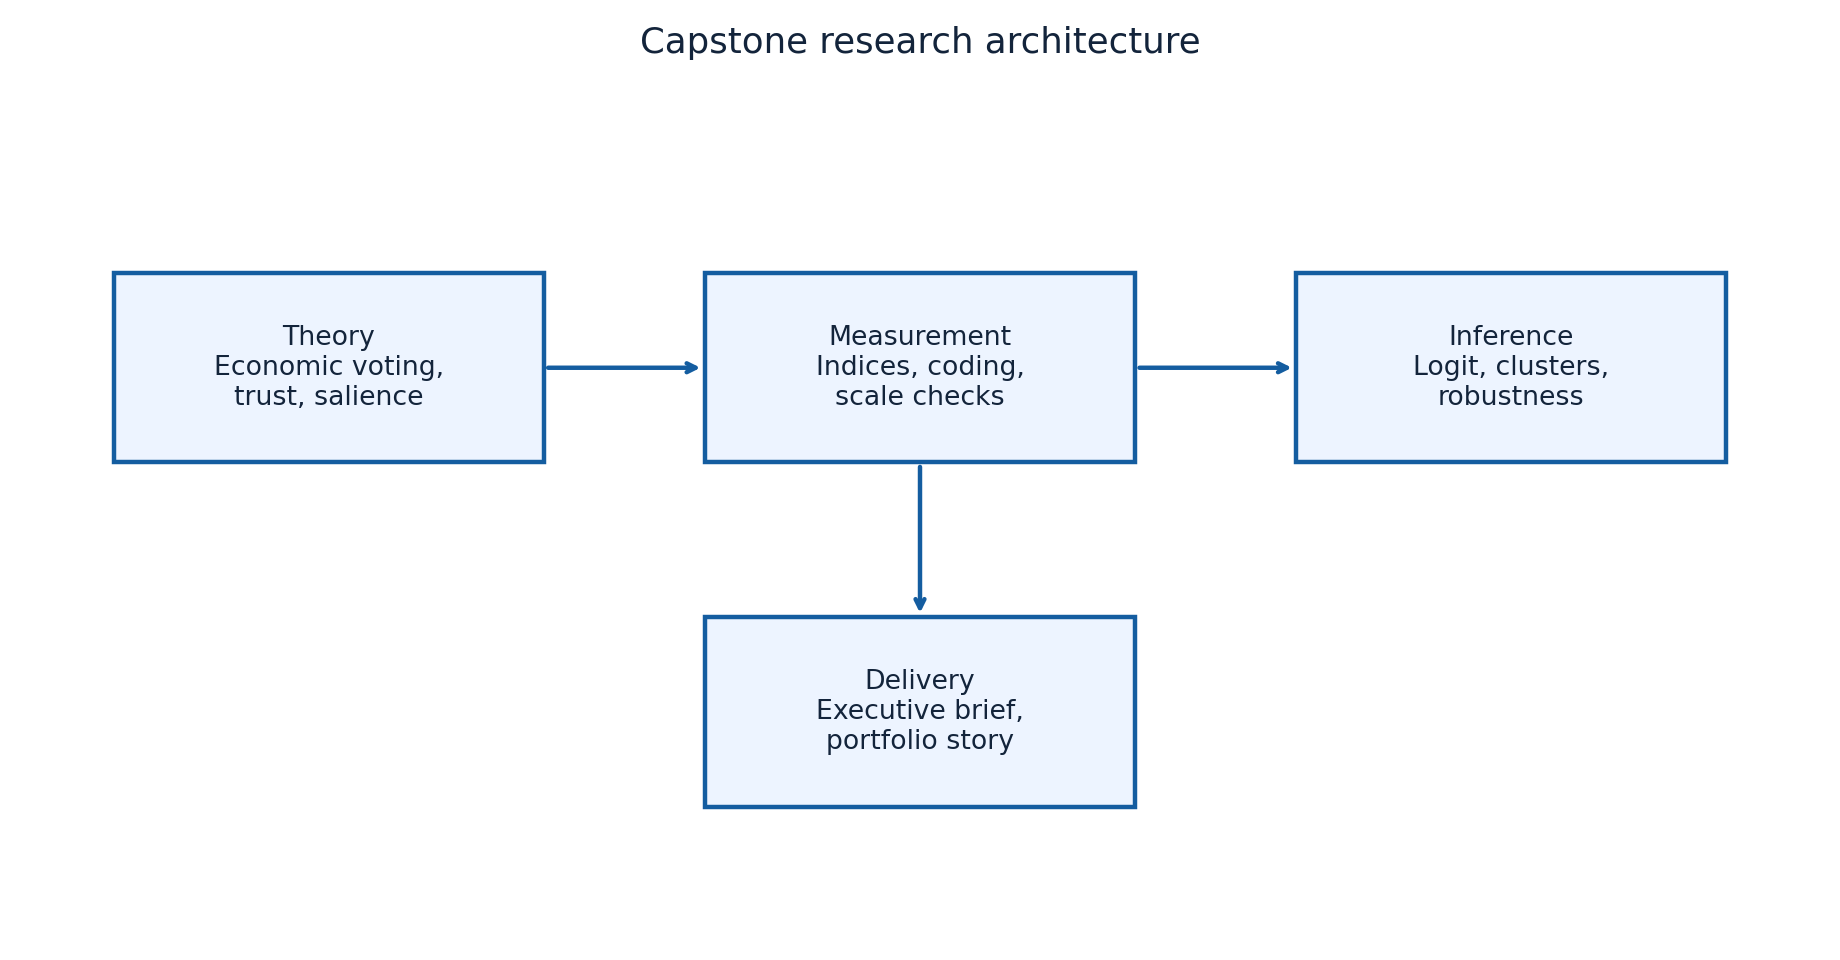

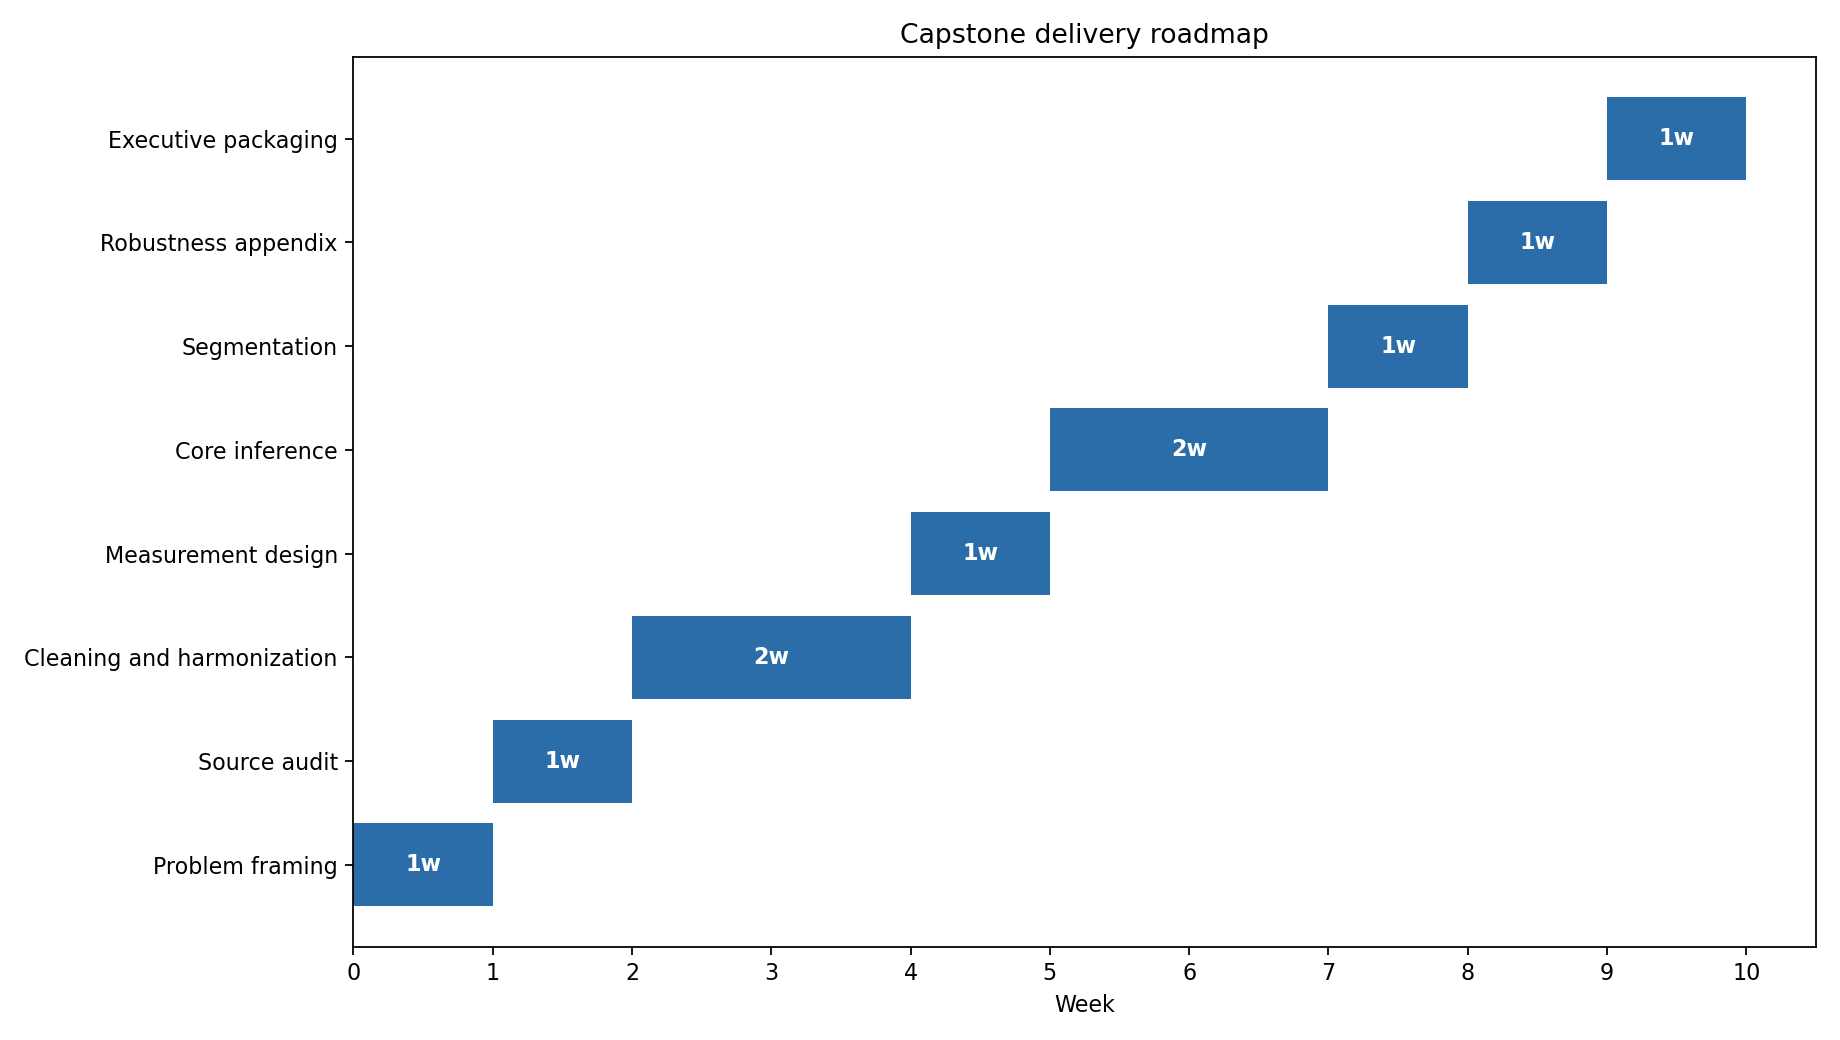

In [6]:
for figure_path in [
    BASE_DIR / 'outputs/figures/capstone_test_strategy.png',
    BASE_DIR / 'outputs/figures/capstone_research_architecture.png',
    BASE_DIR / 'outputs/figures/capstone_delivery_roadmap.png',
]:
    display(Image(filename=str(figure_path), width=900))


## 4. Validity and inferential discipline

The blueprint includes explicit validity risks because a serious capstone should show not only what it plans to estimate, but also what could undermine those claims.

This makes the repository more credible in two ways:

- it reduces the temptation to overstate correlational findings,
- and it shows awareness of sampling, coding, and model-dependence risks before the empirical stage begins.


In [7]:
validity


,risk,threat,mitigation
0,Construct validity,Survey items may not map cleanly onto trust or...,Document coding decisions and test internal co...
1,Selection bias,Nonresponse and low-propensity groups may be u...,"Use weights, compare sample margins to public ..."
2,Model dependence,Conclusions may change with coding thresholds ...,Report alternative specifications and keep a r...
3,Overinterpretation,Correlational results may be framed as causal.,State scope conditions clearly and separate ex...
4,Temporal instability,Campaign dynamics can change quickly around ma...,Anchor findings to survey fieldwork dates and ...


## 5. Execution logic

The delivery roadmap makes the project actionable. Instead of an open-ended research idea, the repository now lays out a sequence from source audit to executive packaging. This is especially useful for a portfolio because it demonstrates that the work can move from theory to execution without major restructuring.


In [8]:
roadmap


,phase,weeks,deliverable
0,Problem framing,1,"Research question, scope, and theoretical memo"
1,Source audit,1,"Dataset shortlist, codebook review, comparabil..."
2,Cleaning and harmonization,2,Reusable scripts and clean analysis sample
3,Measurement design,1,"Indices, coding rules, and diagnostics"
4,Core inference,2,Main regression tables and marginal effects
5,Segmentation,1,Cluster profiles and audience narratives
6,Robustness appendix,1,Sensitivity checks and alternative specifications
7,Executive packaging,1,"Portfolio PDF, README, and presentation"


## 6. Conclusion

This notebook does not pretend the empirical results already exist. That is intentional. Its value is different: it shows a fully specified research design with theory, measurement, methodological sequence, and inferential discipline.

For an academic or professional reader, that is already a strong signal. It shows that the capstone is ready to become an empirical case as soon as the final survey source is fixed.
